<a href="https://colab.research.google.com/github/MishterBluesky/CoEVFold/blob/main/Co_EVFold_Multiplex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  CoEVFold Multiplex 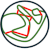

This notebook, derived from MMSEQ2, GREMLIN and ColabFold, performs a GREMLIN direct coupling analysis of coevolution on an input structure, (maximum two genes) and then plots this against the structure to see the level of coevolution agreement.

**Simply upload the .pdb file, select your cutoffs and away!**

Remember, coevolution whilst routed in genetic history is not an absolute sign that your proteins interact! However if this is shown in multiple instances, by alphafold and has agreement that indicates the interactions are more likely.

The output is in the form of a heatmap of coevolution, as well as a .pse file with connections between proteins output as red lines. Limit of 1000a.a combined gene lengths. Note: Selecting A100 GPU High RAM allows for up to 2500a.a combined gene lengths

In [ ]:
%%time
#@title setup
unified_memory = True #@param {type:"boolean"}
import os, time, gc
if unified_memory:
  ENV = {"TF_FORCE_UNIFIED_MEMORY":"1", "XLA_PYTHON_CLIENT_MEM_FRACTION":"4.0"}
  for k,v in ENV.items(): os.environ[k] = v
if not os.path.isdir("params"):
  # get code
  print("installing ColabDesign")
  os.system("(mkdir params; apt-get install aria2 -qq; \
  aria2c -q -x 16 https://storage.googleapis.com/alphafold/alphafold_params_2022-12-06.tar; \
  tar -xf alphafold_params_2022-12-06.tar -C params; touch params/done.txt )&")

  os.system("pip -q install git+https://github.com/sokrypton/ColabDesign.git@gamma")
  os.system("ln -s /usr/local/lib/python3.*/dist-packages/colabdesign colabdesign")
  os.system("wget https://raw.githubusercontent.com/sokrypton/ColabFold/main/colabfold/colabfold.py -O colabfold_utils.py")
  #os.system("wget https://raw.githubusercontent.com/sokrypton/ColabFold/beta/colabfold/mmseqs/api.py")

  # install hhsuite
  print("installing HHsuite")
  os.makedirs("hhsuite", exist_ok=True)
  os.system(f"curl -fsSL https://github.com/soedinglab/hh-suite/releases/download/v3.3.0/hhsuite-3.3.0-SSE2-Linux.tar.gz | tar xz -C hhsuite/")

  # download params
  if not os.path.isfile("params/done.txt"):
    print("downloading AlphaFold params")
    while not os.path.isfile("params/done.txt"):
      time.sleep(5)
if "hhsuite" not in os.environ['PATH']:
  os.environ['PATH'] += ":hhsuite/bin:hhsuite/scripts"

import re, tempfile
from IPython.display import HTML
from google.colab import files
import numpy as np
from colabdesign import mk_af_model, clear_mem
from colabdesign.af.contrib import predict
from colabdesign.af.contrib.cyclic import add_cyclic_offset
from colabdesign.shared.protein import _np_rmsd, _np_kabsch
from colabdesign.shared.plot import plot_pseudo_3D, pymol_cmap


import jax
import jax.numpy as jnp
from colabfold_utils import run_mmseqs2
import matplotlib.pyplot as plt
import string
import numpy as np

def clear_mem():
  backend = jax.lib.xla_bridge.get_backend()
  for buf in backend.live_buffers(): buf.delete()

def get_pdb(pdb_code=""):
  if pdb_code is None or pdb_code == "":
    upload_dict = files.upload()
    pdb_string = upload_dict[list(upload_dict.keys())[0]]
    with open("tmp.pdb","wb") as out: out.write(pdb_string)
    return "tmp.pdb"
  elif os.path.isfile(pdb_code):
    return pdb_code
  elif len(pdb_code) == 4:
    os.makedirs("tmp",exist_ok=True)
    os.system(f"wget -qnc https://files.rcsb.org/download/{pdb_code}.cif -P tmp/")
    return f"tmp/{pdb_code}.cif"
  else:
    os.makedirs("tmp",exist_ok=True)
    os.system(f"wget -qnc https://alphafold.ebi.ac.uk/files/AF-{pdb_code}-F1-model_v4.pdb -P tmp/")
    return f"tmp/AF-{pdb_code}-F1-model_v4.pdb"

def run_hhalign(query_sequence, target_sequence, query_a3m=None, target_a3m=None):
  with tempfile.NamedTemporaryFile() as tmp_query, \
  tempfile.NamedTemporaryFile() as tmp_target, \
  tempfile.NamedTemporaryFile() as tmp_alignment:
    if query_a3m is None:
      tmp_query.write(f">Q\n{query_sequence}\n".encode())
      tmp_query.flush()
      query_a3m = tmp_query.name
    if target_a3m is None:
      tmp_target.write(f">T\n{target_sequence}\n".encode())
      tmp_target.flush()
      target_a3m = tmp_target.name
    os.system(f"hhalign -hide_cons -i {query_a3m} -t {target_a3m} -o {tmp_alignment.name}")
    X, start_indices = predict.parse_hhalign_output(tmp_alignment.name)
  return X, start_indices

def run_do_not_align(query_sequence, target_sequence, **arg):
  return [query_sequence,target_sequence],[0,0]

def run_hhfilter(input, output, id=90, qid=10):
  os.system(f"hhfilter -id {id} -qid {qid} -i {input} -o {output}")

@jax.jit
def get_coevolution(X):
  '''given one-hot encoded MSA, return contacts'''
  Y = jax.nn.one_hot(X,22)
  N,L,A = Y.shape
  Y_flat = Y.reshape(N,-1)
  # covariance
  c = jnp.cov(Y_flat.T)

  # inverse covariance
  shrink = 4.5/jnp.sqrt(N) * jnp.eye(c.shape[0])
  ic = jnp.linalg.inv(c + shrink)

  # partial correlation coefficient
  ic_diag = jnp.diag(ic)
  pcc = ic / jnp.sqrt(ic_diag[:,None] * ic_diag[None,:])

  raw = jnp.sqrt(jnp.square(pcc.reshape(L,A,L,A)[:,:20,:,:20]).sum((1,3)))
  i = jnp.arange(L)
  raw = raw.at[i,i].set(0)
  # do apc
  ap = raw.sum(0,keepdims=True) * raw.sum(1,keepdims=True) / raw.sum()
  return (raw - ap).at[i,i].set(0)

def plot_3D(aux, Ls, file_name, show=False):
  plt.figure(figsize=(10,5))
  xyz = aux["atom_positions"][:,1]
  xyz = xyz @ _np_kabsch(xyz, xyz, return_v=True, use_jax=False)
  ax = plt.subplot(1,2,1)
  if len(Ls) > 1:
    plt.title("chain")
    c = np.concatenate([[n]*L for n,L in enumerate(Ls)])
    plot_pseudo_3D(xyz=xyz, c=c, cmap=pymol_cmap, cmin=0, cmax=39, Ls=Ls, ax=ax)
  else:
    plt.title("length")
    plot_pseudo_3D(xyz=xyz, Ls=Ls, ax=ax)
  plt.axis(False)
  ax = plt.subplot(1,2,2)
  plt.title("plddt")
  plot_pseudo_3D(xyz=xyz, c=aux["plddt"], cmin=0.5, cmax=0.9, Ls=Ls, ax=ax)
  plt.axis(False)
  plt.savefig(file_name, dpi=200, bbox_inches='tight')
  plt.show() if show else plt.close()

installing ColabDesign
installing HHsuite
downloading AlphaFold params
CPU times: user 2.54 s, sys: 179 ms, total: 2.72 s
Wall time: 52.1 s


In [ ]:
# Install Biopython
!pip install biopython

from collections import defaultdict
from Bio.PDB import PDBParser, MMCIFParser, PDBIO
from Bio.Data.IUPACData import protein_letters_3to1
from google.colab import files
import os

# ---------------------------
# Upload structure file
# ---------------------------
uploaded = files.upload()
filename = list(uploaded.keys())[0]
file_ext = os.path.splitext(filename)[1].lower()
print(f"Detected file type: {file_ext}")

# ---------------------------
# Parse structure (convert CIF → PDB if needed)
# ---------------------------
if file_ext == ".cif":
    parser = MMCIFParser(QUIET=True)
    structure = parser.get_structure("structure", filename)

    # Write out converted PDB
    io = PDBIO()
    io.set_structure(structure)
    pdb_filename = filename.replace(".cif", ".pdb")
    io.save(pdb_filename)
    print(f"Converted CIF to PDB: {pdb_filename}")

else:
    pdb_filename = filename

parser = PDBParser(QUIET=True)
structure = parser.get_structure("structure", pdb_filename)

# ---------------------------
# Extract 1-letter sequence for each REAL PDB chain
# Chain breaks are ignored
# ---------------------------
def get_chain_sequence(chain):
    seq = ""
    for res in chain.get_residues():

        # Skip hetero atoms (water, ligands, etc.)
        if res.id[0] != " ":
            continue

        # Convert 3-letter → 1-letter; unknown → X
        resname = res.resname.capitalize()  # e.g., "Ala", "Gly", etc.
        aa = protein_letters_3to1.get(resname, "X")
        seq += aa

    return seq


sequence_to_chains = defaultdict(list)
chain_sequences = {}

for model in structure:
    for chain in model:
        seq = get_chain_sequence(chain)
        if seq:  # Only include chains with residues
            chain_sequences[chain.id] = seq
            sequence_to_chains[seq].append(chain.id)

# ---------------------------
# Build job list and combined query sequence
# ---------------------------
jobs = []
for i, (seq, chains) in enumerate(sequence_to_chains.items(), 1):
    job_id = f"Job_{i}"
    jobs.append((job_id, seq, chains))

query_sequence = ":".join(seq for _, seq, _ in jobs)

# ---------------------------
# Output results
# ---------------------------
print("\n===== Extracted Chain Sequences (ignoring chain breaks) =====")
for chain_id, seq in chain_sequences.items():
    print(f"Chain {chain_id}: length {len(seq)}")
    print(seq)
    print()

print("\n===== Query Sequence =====")
print(query_sequence)

print("\n===== Job Info =====")
for job_id, seq, chains in jobs:
    print(f"{job_id}: {len(chains)} chain(s) "
          f"({', '.join(chains)}) - Length: {len(seq)}")


Saving fold_pseudo_below_model_0.cif to fold_pseudo_below_model_0 (1).cif
Detected file type: .cif
Converted CIF to PDB: fold_pseudo_below_model_0 (1).pdb

===== Extracted Chain Sequences (ignoring chain breaks) =====
Chain A: length 114
MTTRSKLGIALLALGISLSAMAMDLGQAMSALGGAKAQGLVGEQADGYLGVVSNSGQAADIAAQINAARRAEYQKVANSSGASLADVEAMAGKKAMERTPAGQYVQVGGKWVKK

Chain B: length 63
MRLCALFAVLLLGSLTMACTPTVQLAAPSEPININLNVKIEHEIYIKVDKALDGIINENSGLF

Chain C: length 63
MRLCALFAVLLLGSLTMACTPTVQLAAPSEPININLNVKIEHEIYIKVDKALDGIINENSGLF

Chain D: length 855
MRLRRRTTLLLVFAVLLLLAFGYGWHAWRSLLREQGVERLEWQGLGLSAEGIGLRRLALERRGADGASLRLDVEHALLRWPGLSGWRPRLPGLRVEQVALAWQPAAASSDDDSAALDWTSLRETLAWLPEQIHLERFHLDLPCPAGRCEQDGGLDIGRPSGALFPLAAQLRLQQEAQQAQLDAQLFEEPTGWRLRARAQLDRQALLTLDSQLAPSDGDGLWQGRLEAPGLPDTRGLVVWLNRWLPEAQRLPDAPQALRLQADWTIRLAPGSDWLEPRRVLDGGGSAALLVQAPQAWPLPGLGNVQGELQVQLDGDEGAWLPRQLRSDLRLSQLHGEWLQALPAELRPSALGLRSEPLERDADSVTALRLAFTSEGASTLKLETRLDLLGISPWAARLVEGRLQVGAPHLQYQGWKAERLVAEIPLEGRLDGQRANLSFGRGARLQAASLAEPSTLHLG

<>:27: SyntaxWarning: invalid escape sequence '\('
<>:28: SyntaxWarning: invalid escape sequence '\)'
<>:27: SyntaxWarning: invalid escape sequence '\('
<>:28: SyntaxWarning: invalid escape sequence '\)'
/tmp/ipython-input-228547773.py:27: SyntaxWarning: invalid escape sequence '\('
  sequence = re.sub("\(",":(", sequence)
/tmp/ipython-input-228547773.py:28: SyntaxWarning: invalid escape sequence '\)'
  sequence = re.sub("\)","):", sequence)


jobname RodAPBP2_7d468
length=[114, 63, 855] copies=1
getting paired MSA


COMPLETE: 100%|██████████| 450/450 [elapsed: 00:35 remaining: 00:00]


parsing msas
gathering info
filtering sequences
selecting final sequences


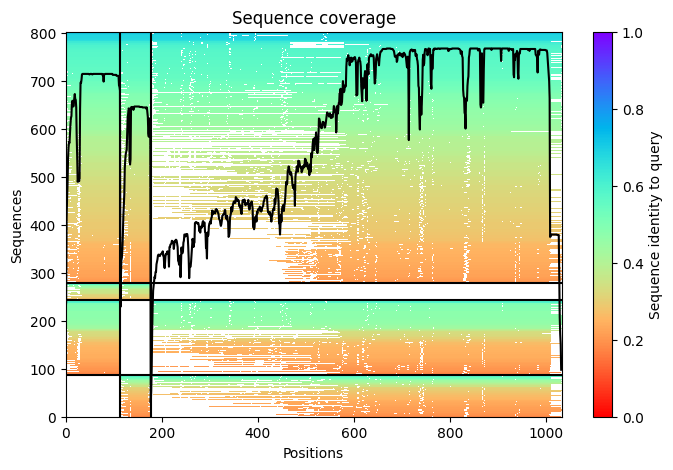

GC 5723


In [ ]:
#@title prep_inputs
jobname = "RodA-PBP2" #@param {type:"string"}
copies = 1
#@markdown **MSA options**
msa_method = "mmseqs2" #@param ["mmseqs2","single_sequence", "custom_fas", "custom_a3m", "custom_sto"]
pair_mode = "paired" #@param ["unpaired_paired","paired","unpaired"] {type:"string"}
#@markdown filtering options
cov = 50 #@param ["0", "25", "50", "75", "90", "99"] {type:"raw"}
id = 99 #@param ["90", "95" "100"] {type:"raw"}
qid = 0 #@param ["0", "10", "15", "20", "30"] {type:"raw"}
do_not_filter = False #@param {type:"boolean"}
sequence = query_sequence
#@markdown ----
#@markdown **Templates options**
template_mode = "none" #@param ["none", "mmseqs2", "custom"] {type:"string"}
use_templates = template_mode in ["mmseqs2","custom"]
pdb = "" #@param {type:"string"}
chain = "A" #@param {type:"string"}
rm_template_seq = False #@param {type:"boolean"}
propagate_to_copies = True #@param {type:"boolean"}
do_not_align = False #@param {type:"boolean"}
rm_sidechain = rm_sequence = rm_template_seq

# filter options
sequence = sequence.upper()
sequence = re.sub("[^A-Z:/()]", "", sequence.upper())
sequence = re.sub("\(",":(", sequence)
sequence = re.sub("\)","):", sequence)
sequence = re.sub(":+",":",sequence)
sequence = re.sub("/+","/",sequence)
sequence = re.sub("^[:/]+","",sequence)
sequence = re.sub("[:/]+$","",sequence)
jobname = re.sub(r'\W+', '', jobname)

# process sequence
sequences = sequence.split(":")
u_sequences = predict.get_unique_sequences(sequences)
u_cyclic = [x.startswith("(") for x in u_sequences]
u_sub_lengths = [[len(y) for y in x.split("/")] for x in u_sequences]
u_sequences = [x.replace("(","").replace(")","").replace("/","") for x in u_sequences]
if len(sequences) > len(u_sequences):
  print("WARNING: use copies to define homooligomers")
u_lengths = [len(x) for x in u_sequences]
sub_seq = "".join(u_sequences)
seq = sub_seq * copies

jobname = f"{jobname}_{predict.get_hash(seq)[:5]}"
def check(folder): return os.path.exists(folder)
if check(jobname):
  n = 0
  while check(f"{jobname}_{n}"): n += 1
  jobname = f"{jobname}_{n}"

print("jobname",jobname)
print(f"length={u_lengths} copies={copies}")

input_opts = {"sequence":u_sequences,
              "copies":copies,
              "msa_method":msa_method,
              "pair_mode":pair_mode,
              "do_not_filter":do_not_filter,
              "cov":cov,
              "id":id,
              "template_mode":template_mode,
              "propagate_to_copies":propagate_to_copies}

def run_mmseqs2_wrapper(*args, **kwargs):
  kwargs['user_agent'] = "colabdesign/gamma"
  return run_mmseqs2(*args, **kwargs)

##################
# GET MSA
##################
os.makedirs(jobname, exist_ok=True)

Ls = [len(x) for x in u_sequences]
if msa_method == "mmseqs2":
  msa, deletion_matrix = predict.get_msa(u_sequences, jobname,
    mode=pair_mode,
    cov=cov, id=id, qid=qid, max_msa=4096,
    do_not_filter=do_not_filter,
    mmseqs2_fn=run_mmseqs2_wrapper,
    hhfilter_fn=run_hhfilter)

elif msa_method == "single_sequence":
  with open(f"{jobname}/msa.a3m","w") as a3m:
    a3m.write(f">{jobname}\n{sub_seq}\n")
  msa, deletion_matrix = predict.parse_a3m(f"{jobname}/msa.a3m")

else:
  msa_format = msa_method.split("_")[1]
  print(f"upload {msa_method}")
  msa_dict = files.upload()
  lines = []
  for k,v in msa_dict.items():
    lines += v.decode().splitlines()
  input_lines = []
  for line in lines:
    line = line.replace("\x00","")
    if len(line) > 0 and not line.startswith('#'):
      input_lines.append(line)
  with open(f"{jobname}/msa.{msa_format}","w") as msa:
    msa.write("\n".join(input_lines))
  if msa_format != "a3m":
    os.system(f"perl hhsuite/scripts/reformat.pl {msa_format} a3m {jobname}/msa.{msa_format} {jobname}/msa.a3m")
  if do_not_filter:
    os.system(f"hhfilter -qid 0 -id 100 -cov 0 -i {jobname}/msa.a3m -o {jobname}/msa.filt.a3m")
  else:
    os.system(f"hhfilter -qid {qid} -id {id} -cov {cov} -i {jobname}/msa.a3m -o {jobname}/msa.filt.a3m")
  msa, deletion_matrix = predict.parse_a3m(f"{jobname}/msa.filt.a3m")

if len(msa) > 1:
  predict.plot_msa(msa, Ls)
  plt.savefig(f"{jobname}/msa_feats.png", dpi=200, bbox_inches='tight')
  plt.show()

##################
if use_templates:
  print("aligning template")
  template_msa = f"{jobname}/msa.a3m"
  if template_mode == "mmseqs2":
    predict.get_msa(u_sequences, jobname,
      mode="unpaired",
      mmseqs2_fn=run_mmseqs2_wrapper,
      do_not_filter=True,
      do_not_return=True,
      output_a3m=f"{jobname}/msa_tmp.a3m")
    template_msa = f"{jobname}/msa_tmp.a3m"
    if not propagate_to_copies and copies > 1:
      new_msa = []
      with open(template_msa, "r") as handle:
        for line in handle:
          if not line.startswith(">"):
            new_msa.append(line.rstrip())
      with open(template_msa, "w") as handle:
        for n,seq in enumerate(new_msa):
          handle.write(f">{n}\n{seq*copies}\n")

    templates = {}
    print("ID\tpdb\tcid\tevalue")
    for line in open(f"{jobname}/msa/_env/pdb70.m8","r"):
      p = line.rstrip().split()
      M,target_id,qid,e_value = p[0],p[1],p[2],p[10]
      M = int(M)
      if M not in templates:
        templates[M] = []
      if len(templates[M]) < 4:
        print(f"{int(M)}\t{target_id}\t{qid}\t{e_value}")
        templates[M].append(target_id)
    if len(templates) == 0:
      use_templates = False
      print("ERROR: no templates found...")
    else:
      Ms = sorted(list(templates.keys()))
      pdbs,chains = [],[]
      for M in Ms:
        for n,target_id in enumerate(templates[M]):
          pdb_id,chain_id = target_id.split("_")
          if len(pdbs) < n+1:
            pdbs.append([])
            chains.append([])
          pdbs[n].append(pdb_id)
          chains[n].append(chain_id)
      print(pdbs)
  else:
    pdbs,chains = [pdb],[chain]

if use_templates:
  input_opts.update({"pdbs":pdbs, "chains":chains})
  batches = []
  for pdb,chain in zip(pdbs,chains):
    query_seq = "".join(u_sequences)
    batch = predict.get_template_feats(pdb, chain,
      query_seq=query_seq,
      query_a3m=template_msa,
      copies=copies,
      propagate_to_copies=propagate_to_copies,
      use_seq=not rm_sequence,
      get_pdb_fn=get_pdb,
      align_fn=run_do_not_align if do_not_align else run_hhalign)
    batches.append(batch)

  # for display
  plt.figure(figsize=(3*len(batches),3))
  for n,batch in enumerate(batches):
    plt.subplot(1,len(batches),n+1)
    plt.title(f"template features {n+1}")
    dgram = batch["dgram"].argmax(-1).astype(float)
    dgram[batch["dgram"].sum(-1) == 0] = np.nan
    Ln = dgram.shape[0]
    plt.imshow(dgram, extent=(0, Ln, Ln, 0))
    predict.plot_ticks(Ls * copies)
  plt.savefig(f"{jobname}/template_feats.png", dpi=200, bbox_inches='tight')
  plt.show()
else:
  batches = [None]

################
print("GC",gc.collect())

In [ ]:
# IMPORTANT, only tested using PYTHON 3!
import numpy as np
import tensorflow.compat.v1 as tf
tf.disable_eager_execution()
import matplotlib.pylab as plt
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from scipy.special import logsumexp
import pandas as pd

In [ ]:
################
# note: if you are modifying the alphabet
# make sure last character is "-" (gap)
################
alphabet = "ARNDCQEGHILKMFPSTWYV-"
states = len(alphabet)

# map amino acids to integers (A->0, R->1, etc)
a2n = dict((a,n) for n,a in enumerate(alphabet))
aa2int = lambda x: a2n.get(x,a2n['-'])

In [ ]:
#@title Convert the MSA results into a co-evolution input
print("jobname",jobname)
filename  = f'{jobname}/msa.a3m'
def parse_a3m(filename):
    names, seqs = [], []
    current_seq = ""

    with open(filename, "r") as file:
        for line in file:
            line = line.rstrip()

            if line.startswith(">"):
                if current_seq:
                    # Remove lowercase letters from the sequence
                    current_seq = ''.join([char if char.isupper() or char == '-' else '' for char in current_seq])
                    if current_seq.strip():  # Check if the current sequence is not empty
                        seqs.append(current_seq)
                    current_seq = ""
                names.append(line[1:])
            else:
                current_seq += line

    if current_seq:
        # Remove lowercase letters from the sequence
        current_seq = ''.join([char if char.isupper() or char == '-' else '' for char in current_seq])
        if current_seq.strip():  # Check if the last sequence is not empty
            seqs.append(current_seq)

    return names, seqs
names, seqs = parse_a3m(filename)


def filt_gaps(msa, gap_cutoff=0.5):
  '''filters alignment to remove gappy positions'''
  frac_gaps = np.mean((msa == states-1).astype(float),0)
  non_gaps = np.where(frac_gaps < gap_cutoff)[0]
  return msa[:,non_gaps], non_gaps

def get_eff(msa, eff_cutoff=0.8):
  '''compute effective weight for each sequence'''
  msa_sm = 1.0 - squareform(pdist(msa,"hamming"))
  msa_w = (msa_sm >= eff_cutoff).astype(float)
  msa_w = 1.0/np.sum(msa_w,-1)
  return msa_w

def str2int(x):
  '''convert a list of strings into list of integers'''
  # Example: ["ACD","EFG"] -> [[0,4,3], [6,13,7]]
  if x.dtype.type is np.str_:
    if x.ndim == 0: return np.array([aa2int(aa) for aa in x])
    else: return np.array([[aa2int(aa) for aa in seq] for seq in x])
  else:
    return x

def split_train_test(seqs, frac_test=0.1):
  # shuffle data
  x = np.copy(seqs)
  np.random.shuffle(x[1:])

  # fraction of data used for testing
  split = int(len(x) * (1.0-frac_test))

  # split training/test datasets
  return x[:split], x[split:]

def mk_msa(seqs, gap_cutoff=0.5, eff_cutoff=0.8):
  '''converts list of sequences to MSA (Multiple Sequence Alignment)'''
  # =============================================================================
  # The function takes a list of sequences (strings) and returns a (dict)ionary
  # containing the following:
  # =============================================================================
  # BEFORE GAP REMOVAL
  # -----------------------------------------------------------------------------
  # msa_ori   msa
  # ncol_ori  number of columns
  # -----------------------------------------------------------------------------
  # AFTER GAP REMOVAL
  # By default, columns with ≥ 50% gaps are removed. This makes things a
  # little complicated, as we need to keep track of which positions were removed.
  # -----------------------------------------------------------------------------
  # msa       msa
  # ncol      number of columns
  # v_idx     index of positions kept
  # -----------------------------------------------------------------------------
  # weights   weight for each sequence (based on sequence identity)
  # nrow      number of rows (sequences)
  # neff      number of effective sequences sum(weights)
  # =============================================================================

  msa_ori = str2int(seqs)

  # remove positions with more than > 50% gaps
  msa, v_idx = filt_gaps(msa_ori)

  # compute effective weight for each sequence
  msa_weights = get_eff(msa, eff_cutoff)

  return {"msa_ori":msa_ori,
          "msa":msa,
          "weights":msa_weights,
          "neff":np.sum(msa_weights),
          "v_idx":v_idx,
          "nrow":msa.shape[0],
          "ncol":msa.shape[1],
          "ncol_ori":msa_ori.shape[1]}

jobname RodAPBP2_7d468


In [ ]:
#@title optimizer
def opt_adam(loss, name, var_list=None, lr=1.0, b1=0.9, b2=0.999, b_fix=False):
  # adam optimizer
  # Note: this is a modified version of adam optimizer. More specifically, we replace "vt"
  # with sum(g*g) instead of (g*g). Furthmore, we find that disabling the bias correction
  # (b_fix=False) speeds up convergence for our case.

  if var_list is None: var_list = tf.trainable_variables()
  gradients = tf.gradients(loss,var_list)
  if b_fix: t = tf.Variable(0.0,"t")
  opt = []
  for n,(x,g) in enumerate(zip(var_list,gradients)):
    if g is not None:
      ini = dict(initializer=tf.zeros_initializer,trainable=False)
      mt = tf.get_variable(name+"_mt_"+str(n),shape=list(x.shape), **ini)
      vt = tf.get_variable(name+"_vt_"+str(n),shape=[], **ini)

      mt_tmp = b1*mt+(1-b1)*g
      vt_tmp = b2*vt+(1-b2)*tf.reduce_sum(tf.square(g))
      lr_tmp = lr/(tf.sqrt(vt_tmp) + 1e-8)

      if b_fix: lr_tmp = lr_tmp * tf.sqrt(1-tf.pow(b2,t))/(1-tf.pow(b1,t))

      opt.append(x.assign_add(-lr_tmp * mt_tmp))
      opt.append(vt.assign(vt_tmp))
      opt.append(mt.assign(mt_tmp))

  if b_fix: opt.append(t.assign_add(1.0))
  return(tf.group(opt))

In [ ]:
#@title GREMLIN - change iterations to 100 when done testing
def GREMLIN(msa,
            opt_iter=100,
            opt_rate=1.0,
            batch_size=None,
            lam_v=0.01,
            lam_w=0.01,
            scale_lam_w=True,
            v=None,
            w=None,
            ignore_gap=True):

  '''fit params of MRF (Markov Random Field) given MSA (multiple sequence alignment)'''
  # ==========================================================================
  # this function takes a MSA (dict)ionary, from mk_msa() and returns a MRF
  # (dict)ionary containing the following:
  # ==========================================================================
  # len       full length
  # v_idx     index of positions (mapping back to full length)
  # v         2-body term
  # w         2-body term
  # ==========================================================================
  # WARNING: The mrf is over the msa after gap removal. "v_idx" and "len" are
  # important for mapping the MRF back to the original MSA.
  # ==========================================================================

  ########################################
  # SETUP COMPUTE GRAPH
  ########################################
  # reset tensorflow graph
  tf.reset_default_graph()

  # length of sequence
  ncol = msa["ncol"]

  # input msa (multiple sequence alignment)
  MSA = tf.placeholder(tf.int32,shape=(None,ncol),name="msa")

  # input msa weights
  MSA_weights = tf.placeholder(tf.float32, shape=(None,), name="msa_weights")

  # one-hot encode msa
  OH_MSA = tf.one_hot(MSA,states)

  if ignore_gap:
    ncat = states - 1
    NO_GAP = 1.0 - OH_MSA[...,-1]
    OH_MSA = OH_MSA[...,:ncat]

  else:
    ncat = states

  ########################################
  # V: 1-body-term of the MRF
  ########################################
  V = tf.get_variable(name="V",
                          shape=[ncol,ncat],
                          initializer=tf.zeros_initializer)

  ########################################
  # W: 2-body-term of the MRF
  ########################################
  W_tmp = tf.get_variable(name="W",
                          shape=[ncol,ncat,ncol,ncat],
                          initializer=tf.zeros_initializer)

  # symmetrize W
  W = W_tmp + tf.transpose(W_tmp,[2,3,0,1])

  # set diagonal to zero
  W = W * (1-np.eye(ncol))[:,None,:,None]

  ########################################
  # Pseudo-Log-Likelihood
  ########################################
  # V + W
  VW = V + tf.tensordot(OH_MSA,W,2)

  # hamiltonian
  H = tf.reduce_sum(OH_MSA*VW,-1)

  # local Z (parition function)
  Z = tf.reduce_logsumexp(VW,-1)

  PLL = H - Z
  if ignore_gap:
    PLL = PLL * NO_GAP

  PLL = tf.reduce_sum(PLL,-1)
  PLL = tf.reduce_sum(MSA_weights * PLL)/tf.reduce_sum(MSA_weights)

  ########################################
  # Regularization
  ########################################
  L2 = lambda x: tf.reduce_sum(tf.square(x))
  L2_V = lam_v * L2(V)
  L2_W = lam_w * L2(W) * 0.5

  if scale_lam_w:
    L2_W = L2_W * (ncol-1) * (states-1)

  ########################################
  # Loss Function
  ########################################
  # loss function to minimize
  loss = -PLL + (L2_V + L2_W) / msa["neff"]

  # optimizer
  opt = opt_adam(loss,"adam",lr=opt_rate)

  ########################################
  # Input Generator
  ########################################
  all_idx = np.arange(msa["nrow"])
  def feed(feed_all=False):
    if batch_size is None or feed_all:
      return {MSA:msa["msa"], MSA_weights:msa["weights"]}
    else:
      batch_idx = np.random.choice(all_idx,size=batch_size)
      return {MSA:msa["msa"][batch_idx], MSA_weights:msa["weights"][batch_idx]}

  ########################################
  # OPTIMIZE
  ########################################
  with tf.Session() as sess:

    # initialize variables V and W
    sess.run(tf.global_variables_initializer())

    # initialize V
    if v is None:
      oh_msa = np.eye(states)[msa["msa"]]
      if ignore_gap: oh_msa = oh_msa[...,:-1]

      pseudo_count = 0.01 * np.log(msa["neff"])
      f_v = np.einsum("nla,n->la",oh_msa,msa["weights"])
      V_ini = np.log(f_v + pseudo_count)
      if lam_v > 0:
        V_ini = V_ini - np.mean(V_ini,axis=-1,keepdims=True)
      sess.run(V.assign(V_ini))

    else:
      sess.run(V.assign(v))

    # initialize W
    if w is not None:
      sess.run(W_tmp.assign(w * 0.5))

    # compute loss across all data
    get_loss = lambda: np.round(sess.run(loss,feed(True)) * msa["neff"],2)

    print("starting",get_loss())
    for i in range(opt_iter):
      sess.run(opt,feed())
      if (i+1) % int(opt_iter/10) == 0:
        print("iter",(i+1),get_loss())

    # save the V and W parameters of the MRF
    V_ = sess.run(V)
    W_ = sess.run(W)

  ########################################
  # return MRF
  ########################################
  no_gap_states = states - 1
  mrf = {"v": V_[:,:no_gap_states],
         "w": W_[:,:no_gap_states,:,:no_gap_states],
         "v_idx": msa["v_idx"],
         "len": msa["ncol_ori"]}

  return mrf

In [ ]:
headers, seqs = parse_a3m(filename)

train_seqs, test_seqs = split_train_test(seqs, frac_test=0.1)

msa = mk_msa(train_seqs, gap_cutoff=0.5, eff_cutoff=0.8)


In [ ]:
%%time
# ==========================================================================
# RUN GREMLIN
# ==========================================================================
mrf = GREMLIN(msa,lam_w=0.01)

# NOTE: lam_v (for one-body term) lam_w (for two-body term) can be used to regularize the model
#
# for contact prediction we find lam_w = 0.01 to be most optimial
# (even though it's technically overfitting on the data!)
# the overfitting is partly corrected by APC
#
# for design/scoring you may want to bump the lam_w to a higher value!


starting 621209.53
iter 10 358226.15
iter 20 326655.03
iter 30 317783.63
iter 40 313134.68
iter 50 311944.04
iter 60 311425.23
iter 70 311228.49
iter 80 311153.58
iter 90 311117.32
iter 100 311099.08
CPU times: user 6.34 s, sys: 3.62 s, total: 9.96 s
Wall time: 13.2 s


In [ ]:
def score(mrf, x, recompute_z=False):
  x = str2int(x)

  # if length of sequence != length of model
  if x.shape[-1] != len(mrf["v_idx"]):
    x = x[...,mrf["v_idx"]]

  # one hot encode
  x = np.eye(states)[x]

  # get non-gap positions
  no_gap = 1.0 - x[...,-1]

  # remove gap from one-hot-encoding
  x = x[...,:-1]

  # compute score
  vw = mrf["v"] + np.tensordot(x,mrf["w"],2)

  # ============================================================================================
  # Note, Z (the partition function) is a constant. In GREMLIN, V, W & Z are estimated using all
  # the original weighted input sequence(s). It is NOT recommended to recalculate Z with a
  # different set of sequences. Given the common ERROR of recomputing Z, we include the option
  # to do so, for comparison.
  # ============================================================================================
  h = np.sum(np.multiply(x,vw),axis=-1)
  if recompute_z:
    z = logsumexp(vw, axis=-1)
    return np.sum((h-z), axis=-1)
  else:
    return np.sum(h, axis=-1)

In [ ]:
#@title GREMLIN contact map
def normalize(x):
  x = stats.boxcox(x - np.amin(x) + 1.0)[0]
  x_mean = np.mean(x)
  x_std = np.std(x)
  return((x-x_mean)/x_std)

def get_mtx(mrf):
  '''convert MRF (Markov Random Field) to MTX (Matrix or Contact-map)'''

  # raw (l2norm of each 20x20 matrix)
  raw_sq = np.sqrt(np.sum(np.square(mrf["w"]),(1,3)))
  raw = squareform(raw_sq, checks=False)

  # apc (average product correction)
  ap_sq = np.sum(raw_sq,0,keepdims=True) * np.sum(raw_sq,1,keepdims=True)/np.sum(raw_sq)
  apc = squareform(raw_sq - ap_sq, checks=False)

  i, j = np.triu_indices_from(raw_sq,k=1)
  mtx = {
         "i": mrf["v_idx"][i],
         "j": mrf["v_idx"][j],
         "raw": raw,
         "apc": apc,
         "zscore": normalize(apc),
         "len": mrf["len"]
  }
  return mtx

def plot_mtx(mtx):
  '''plot the mtx'''
  plt.figure(figsize=(5,5))
  for n, key in enumerate(["zscore"]):

    # create empty mtx
    m = np.ones((mtx["len"],mtx["len"])) * np.nan

    # populate
    m[mtx["i"],mtx["j"]] = mtx[key]
    m[mtx["j"],mtx["i"]] = m[mtx["i"],mtx["j"]]

    #plot
    plt.plot
    plt.title("Co-Evolution Matrix (GREMLIN_ZScore)")
    if key == "zscore": plt.imshow(m, cmap='Blues', vmin=0.5, vmax=3)
    else: plt.imshow(m, cmap='Blues')
    plt.grid(False)
    if ':' in query_sequence:
     plt.xlabel("Protein Amino acids")
  plt.savefig(f'co-ev{jobname}.png')
  plt.show()


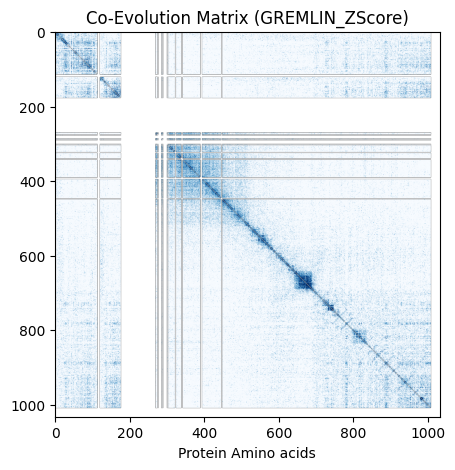

In [ ]:
query_sequence = sequence
mtx = get_mtx(mrf)
plot_mtx(mtx)

In [ ]:
######################################################################################
# WARNING - WARNING - WARNING
######################################################################################
# - the index starts at 0
# - the "first" position is 0
# - in bioinformatics, the first position of a sequence is often "1"
#   for this index use i_aa and j_aa!

# adding amino acid to index+1 this is done again in the next step #message from Chris LB Graham
seq = seqs[0]
mtx["i_aa"] = [f"{seq[i]}_{i+1}" for i in mtx["i"]]
mtx["j_aa"] = [f"{seq[j]}_{j+1}" for j in mtx["j"]]

# load mtx into pandas dataframe
pd_mtx = pd.DataFrame(mtx,columns=["i","j","raw","apc","zscore","i_aa","j_aa"])
coev_mtx = pd.DataFrame(mtx,columns=["i","j","zscore"])

In [ ]:
!python -m pip install --upgrade pip
!pip install tr-rosetta-pytorch
!apt-get install pymol

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 45.5 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 MB 9.2 MB/s  0:00:09
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [tr-rosetta-pytorch]
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  apbs apbs-data at-spi2-core freeglut3 gsettings-desktop-schemas libapbs3
  libatk-bridge2.0-0 libatk1.0-0 libatk1.0-data libatspi2.0-0
  libdouble-conversion3 libevdev2 libglew2.2 libglu1-mesa libgtk-3-0
  libgtk-3-bin libgtk-3-common libgudev-1.0-0 libinput-bin libinput10
  libmaloc1 libmd4c0 libmtdev1 libqt5core5a libqt5dbus5 libqt5designer5
  libqt5gui5 libqt5help5 libqt5network5 libqt5opengl5 libqt5printsupport5
  libqt5sql5 libqt5sql5-sqlite libqt5svg5 libqt5test5 libqt5widg

In [ ]:
!pip install biopython matplotlib numpy


In [ ]:
from Bio.PDB import PDBParser, PDBIO, Select

# Parse original structure
parser = PDBParser(QUIET=True)
structure = parser.get_structure("structure", pdb_filename)

# Renumber residues per chain
for model in structure:
    for chain in model:
        new_id = 1
        for residue in chain.get_residues():
            if residue.id[0] == ' ':  # Only standard residues (ignore hetero/water)
                residue.id = (' ', new_id, ' ')
                new_id += 1

# Save to new file
renumbered_filename = pdb_filename
io = PDBIO()
io.set_structure(structure)
io.save(renumbered_filename)
print(f"Saved renumbered PDB: {renumbered_filename}")

Saved renumbered PDB: fold_pseudo_below_model_0 (1).pdb


In [ ]:
import numpy as np
import pandas as pd

# Threshold for filtering coevolving residues
GREM_threshold = 2  # @param

# Load your matrix, assuming 'i', 'j', 'zscore' columns exist
new_df = pd_mtx[['i', 'j', 'zscore']].copy()

# Parse query sequence into individual job sequences
job_seqs = query_sequence.split(':')
job_boundaries = np.cumsum([0] + [len(seq) for seq in job_seqs])  # Get index boundaries per job

# Container for final results
results = []

# Loop over all unique inter-job pairs (i < j)
for i in range(len(job_seqs)):
    for j in range(i+1, len(job_seqs)):
        start_i, end_i = job_boundaries[i], job_boundaries[i+1]
        start_j, end_j = job_boundaries[j], job_boundaries[j+1]

        # Filter interactions between job_i and job_j
        df = new_df[
            (new_df['i'] >= start_i) & (new_df['i'] < end_i) &
            (new_df['j'] >= start_j) & (new_df['j'] < end_j) &
            ((new_df['j'] - new_df['i']) > 5) &
            (new_df['zscore'] > GREM_threshold)
        ].copy()

        if df.empty:
            continue

        # Adjust residue indices to be local to their respective jobs
        df['Aaa-B'] = df['i'] - start_i + 1  # 1-based indexing
        df['A-Baa'] = df['j'] - start_j + 1
        df['A-B-Score'] = df['zscore']

        # Select and reorder columns
        df = df[['Aaa-B', 'A-Baa', 'A-B-Score']]

        job_pair_label = f"{i+1}-{j+1}"
        df.columns = [f"{job_pair_label}-Aaa-B", f"{job_pair_label}-A-Baa", f"{job_pair_label}-A-B-Score"]

        # Store result
        results.append(df)

# Concatenate all inter-job interactions
if results:
    final_df = pd.concat(results, axis=1)
    final_df.to_csv('sorted_file.csv', sep=' ', index=False)
    print(final_df)
else:
    print("No inter-job interactions above threshold.")


        1-2-Aaa-B  1-2-A-Baa  1-2-A-B-Score  1-3-Aaa-B  1-3-A-Baa  \
6259         10.0       58.0       2.552582        NaN        NaN   
9675         14.0       12.0       2.170252        NaN        NaN   
9679         14.0       16.0       2.038841        NaN        NaN   
9688         14.0       25.0       2.177457        NaN        NaN   
14009        19.0       41.0       2.329925        NaN        NaN   
...           ...        ...            ...        ...        ...   
132903        NaN        NaN            NaN        NaN        NaN   
132907        NaN        NaN            NaN        NaN        NaN   
132926        NaN        NaN            NaN        NaN        NaN   
132930        NaN        NaN            NaN        NaN        NaN   
132943        NaN        NaN            NaN        NaN        NaN   

        1-3-A-B-Score  2-3-Aaa-B  2-3-A-Baa  2-3-A-B-Score  
6259              NaN        NaN        NaN            NaN  
9675              NaN        NaN        NaN      

In [ ]:
import pandas as pd
from google.colab import files
!curl -L -O "https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-$(uname)-$(uname -m).sh"
!bash Miniforge3-Linux-x86_64.sh -b -p /content/mambaforge -u

# Force PATH update in the shell
!export PATH=/content/mambaforge/bin:$PATH

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 81.7M  100 81.7M    0     0  54.9M      0  0:00:01  0:00:01 --:--:--  139M
PREFIX=/content/mambaforge
Unpacking bootstrapper...
Unpacking payload...
Extracting _libgcc_mutex-0.1-conda_forge.tar.bz2
Extracting ca-certificates-2025.11.12-hbd8a1cb_0.conda
Extracting libgomp-15.2.0-he0feb66_15.conda
Extracting nlohmann_json-abi-3.12.0-h0f90c79_1.conda
Extracting pybind11-abi-11-hc364b38_1.conda
Extracting python_abi-3.12-8_cp312.conda
Extracting tzdata-2025b-h78e105d_0.conda
Extracting _openmp_mutex-4.5-2_gnu.tar.bz2
Extracting libgcc-15.2.0-he0feb66_15.conda
Extracting bzip2-1.0.8-hda65f42_8.conda
Extracting c-ares-1.34.5-hb9d3cd8_0.conda
Extracting keyutils-1.6.3-hb9d3cd8_0

In [ ]:
from Bio.PDB import PDBParser, PDBIO, Select

# Define selector that includes only standard amino acids
class OnlyAminoAcids(Select):
    def accept_residue(self, residue):
        return residue.id[0] == ' '  # Only accept standard residues (no HETATM)

# Parse the structure
parser = PDBParser(QUIET=True)
structure = parser.get_structure("structure", pdb_filename)

# Save only amino acids to new PDB
io = PDBIO()
io.set_structure(structure)
io.save(pdb_filename, OnlyAminoAcids())

print(f"Saved cleaned PDB without non-amino acids: {pdb_filename}")

Saved cleaned PDB without non-amino acids: fold_pseudo_below_model_0 (1).pdb


In [ ]:
from collections import defaultdict
from Bio.Data.IUPACData import protein_letters_3to1

# ---------------------------
# Extract sequences per TRUE chain (ignoring chain breaks)
# ---------------------------
def get_chain_sequence(chain):
    seq = ""
    for res in chain.get_residues():
        if res.id[0] != " ":   # Skip ligands, waters
            continue
        aa = protein_letters_3to1.get(res.resname.capitalize(), "X")
        seq += aa
    return seq

sequence_to_chains = defaultdict(list)
chain_sequences = {}

for model in structure:
    for chain in model:
        seq = get_chain_sequence(chain)
        if seq:
            chain_sequences[chain.id] = seq
            sequence_to_chains[seq].append(chain.id)

# ---------------------------
# Build jobs based on unique sequences
# ---------------------------
jobs = []
for i, (seq, chains) in enumerate(sequence_to_chains.items(), start=1):
    job_id = f"Job_{i}"
    jobs.append((job_id, seq, chains))

# ---------------------------
# Build job_info (NEEDED for PyMOL code)
# ---------------------------
job_info = [
    {
        "job_id": job_id,
        "sequence_length": len(seq),
        "chains": chains
    }
    for job_id, seq, chains in jobs
]

print("Job Info Rebuilt:")
for j in job_info:
    print(j)

import pandas as pd
from google.colab import files
import random
import os
import sys

# ---------------------------
# PyMOL installation environment fixes
# ---------------------------
os.environ['PATH'] = f"/content/mambaforge/bin:{os.environ['PATH']}"
sys.path.append('/content/mambaforge/lib/python3.10/site-packages')

# Clear PYTHONPATH to prevent conflicts
if 'PYTHONPATH' in os.environ:
    del os.environ['PYTHONPATH']

!which mamba
!mamba --version
!mamba install -c conda-forge pymol-open-source -y
!mamba install -c conda-forge tqdm -y

# ---------------------------
# Parameters
# ---------------------------
GREM_threshold = 3     #@param Interaction score cutoff
Angstrom_cutoff = 30     #@param Distance measurement cutoff
jobname = os.path.splitext(pdb_filename)[0]  # Name from uploaded PDB

# ---------------------------
# Load GREMLIN output
# ---------------------------
df = pd.read_csv('sorted_file.csv', sep=' ')

# ---------------------------
# PyMOL script assembly
# ---------------------------
color_list = [
    "red", "blue", "green", "orange", "purple", "cyan", "yellow",
    "magenta", "lime", "salmon", "deepsalmon", "tv_blue", "marine",
    "hotpink", "wheat", "forest", "chocolate", "slate"
]

pym_script = []
pym_script.append(f"cmd.load('{pdb_filename}')")
pym_script.append('cmd.color("gray90")')
pym_script.append('cmd.cartoon("automatic")')
pym_script.append('cmd.set("dash_radius", 0.4)')
pym_script.append('cmd.bg_color("white")')

# ---------------------------
# Extract job pair prefixes
# ---------------------------
job_pairs = set()
for col in df.columns:
    if col.endswith('-A-B-Score'):
        pair = col.replace('-A-B-Score', '')
        job_pairs.add(pair)

job_pair_colors = {
    pair: color_list[i % len(color_list)]
    for i, pair in enumerate(sorted(job_pairs))
}

# ---------------------------
# Map job IDs → chain list from new job_info format
# ---------------------------
# job_info looks like: { "job_id": "Job_1", "sequence_length": XX, "chains": ["A","C"] }
job_id_to_chains = {
    entry["job_id"]: entry["chains"]
    for entry in job_info
}

# ---------------------------
# Generate PyMOL measurements
# ---------------------------
for pair in job_pairs:

    # GREMLIN columns
    A_col = f"{pair}-Aaa-B"
    B_col = f"{pair}-A-Baa"
    score_col = f"{pair}-A-B-Score"

    # Skip missing columns
    if not all(col in df.columns for col in [A_col, B_col, score_col]):
        continue

    # Filter hits
    subset = df[[A_col, B_col, score_col]].dropna()
    subset = subset[subset[score_col] > GREM_threshold]

    # Parse job IDs (example: "1-2" → Job_1 and Job_2)
    job1_idx, job2_idx = pair.split('-')
    job1_id = f"Job_{job1_idx}"
    job2_id = f"Job_{job2_idx}"

    chain_set_1 = job_id_to_chains.get(job1_id, [])
    chain_set_2 = job_id_to_chains.get(job2_id, [])

    color = job_pair_colors[pair]

    # Build distance commands
    for _, row in subset.iterrows():
        resA = int(row[A_col])
        resB = int(row[B_col])

        for c1 in chain_set_1:
            for c2 in chain_set_2:
                label = f"d{resA}-{resB}_{c1}{c2}_{pair}"

                pym_script.append(
                    f'cmd.distance("{label}", '
                    f'"resi {resA} and name CA and chain {c1}", '
                    f'"resi {resB} and name CA and chain {c2}", '
                    f'{Angstrom_cutoff})'
                )
                pym_script.append(
                    f'cmd.set("dash_color", "{color}", "{label}")'
                )

# ---------------------------
# Save PyMOL session file
# ---------------------------
pym_script.append(f'cmd.save("{jobname}.pse")')

# Write script to disk
with open("script.py", "w") as out:
    out.write("\n".join(pym_script))

# Run PyMOL headless
!pymol -cq script.py

# Download session
files.download(f"{jobname}.pse")


Job Info Rebuilt:
{'job_id': 'Job_1', 'sequence_length': 114, 'chains': ['A']}
{'job_id': 'Job_2', 'sequence_length': 63, 'chains': ['B', 'C']}
{'job_id': 'Job_3', 'sequence_length': 855, 'chains': ['D']}
/content/mambaforge/bin/mamba
2.4.0
[+] 0.0s
[+] 0.1s
conda-forge/linux-64   1%
conda-forge/noarch    ⣾  [+] 0.2s
conda-forge/linux-64   6%
conda-forge/noarch     9%[+] 0.3s
conda-forge/linux-64  17%
conda-forge/noarch    34%[+] 0.4s
conda-forge/linux-64  29%
conda-forge/noarch    58%[+] 0.5s
conda-forge/linux-64  41%
conda-forge/noarch    84%[+] 0.6s
conda-forge/linux-64  47%
conda-forge/noarch    96%conda-forge/noarch                                
[+] 0.7s
conda-forge/linux-64  61%[+] 0.8s
conda-forge/linux-64  84%[+] 0.9s
conda-forge/linux-64 100%[+] 1.0s
conda-forge/linux-64 100%[+] 1.1s
conda-forge/linux-64 100%conda-forge/linux-64                              

Pinned packages:

  - python=3.12


Transaction

  Prefix: /content/mambaforge

  Updating specs:

   - pymol-open-so

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>